


CSV format (sequential):
 `length, avg, stdev, min, max, valid`  

CSV format (parallel):
 `threads, length, avg, stdev, min, max, valid`

# Utilities

In [1]:
import subprocess
import os
import random
import re
import math
import statistics
import time
import csv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams.update({
    "figure.dpi"       : 130,
    "axes.grid"        : True,
    "grid.alpha"       : 0.35,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

In [2]:
# ── Shared utilities ──────────────────────────────────────────────────────

# Input cache — same seeded random signal for every benchmark
_input_cache = {}

def _gen_signal(length: int) -> str:
    """Returns newline-joined floats for a seeded random signal."""
    if length not in _input_cache:
        random.seed(length)
        vals = [round(random.uniform(-100, 100), 6) for _ in range(length)]
        _input_cache[length] = "\n".join(map(str, vals))
    return _input_cache[length]

def build_input_sequential(length: int) -> str:
    """For sequential C++ files: reads signal_length then signal values."""
    return f"{length}\n{_gen_signal(length)}"

def build_input_parallel(length: int, threads: int) -> str:
    """For parallel C++ files: reads signal_length, values, then num_threads."""
    return f"{length}\n{_gen_signal(length)}\n{threads}"

def build_input_parallel_no_signal(length: int, threads: int) -> str:
    """For C++ files that generate their own signal internally.
       Reads only: signal_length then num_threads."""
    return f"{length}\n{threads}"

def parse_time(output: str):
    m = re.search(r"Time:\s*([\d.eE+\-]+)\s*seconds", output)
    return float(m.group(1)) if m else None

def compile_cpp(cpp_file: str, binary: str, flags: list):
    assert os.path.isfile(cpp_file), f"Not found: {cpp_file}"
    cmd = ["g++", cpp_file, "-o", binary] + flags
    print("Compiling:", " ".join(cmd))
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(f"[COMPILE ERROR]\n{res.stderr}")
    print("[OK] Compiled\n")

def run_once(binary: str, stdin_data: str, timeout: int = 120):
    try:
        r = subprocess.run([binary], input=stdin_data,
                           capture_output=True, text=True, timeout=timeout)
        return parse_time(r.stdout) if r.returncode == 0 else None
    except subprocess.TimeoutExpired:
        return None

def benchmark_sequential(binary: str, length: int, num_runs: int) -> dict:
    data = build_input_sequential(length)
    run_once(binary, data)  # warmup
    times = [t for _ in range(num_runs) if (t := run_once(binary, data)) is not None]
    if not times:
        return dict(length=length, avg=None, stdev=None, min=None, max=None, valid=0)
    return dict(
        length=length,
        avg=statistics.mean(times),
        stdev=statistics.stdev(times) if len(times) > 1 else 0.0,
        min=min(times), max=max(times), valid=len(times),
    )

def benchmark_parallel(binary: str, threads: int, length: int, num_runs: int) -> dict:
    data = build_input_parallel_no_signal(length, threads)
    run_once(binary, data)  # warmup
    times = [t for _ in range(num_runs) if (t := run_once(binary, data)) is not None]
    if not times:
        return dict(threads=threads, length=length, avg=None, stdev=None, min=None, max=None, valid=0)
    return dict(
        threads=threads, length=length,
        avg=statistics.mean(times),
        stdev=statistics.stdev(times) if len(times) > 1 else 0.0,
        min=min(times), max=max(times), valid=len(times),
    )

def save_csv_sequential(results: list, path: str):
    """CSV format: length, avg, stdev, min, max, valid"""
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["length","avg","stdev","min","max","valid"])
        writer.writeheader()
        writer.writerows(results)
    print(f"[CSV] Saved {len(results)} rows → {path}")

def save_csv_parallel(results: list, path: str):
    """CSV format: threads, length, avg, stdev, min, max, valid"""
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["threads","length","avg","stdev","min","max","valid"])
        writer.writeheader()
        writer.writerows(results)
    print(f"[CSV] Saved {len(results)} rows → {path}")

def load_csv_sequential(path: str) -> dict:
    """Returns {length: avg_time}"""
    result = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            if row["avg"] not in ("", "None"):
                result[int(row["length"])] = float(row["avg"])
    return result

def load_csv_parallel(path: str) -> dict:
    """Returns {(threads, length): avg_time}"""
    result = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            if row["avg"] not in ("", "None", "nan"):
                result[(int(row["threads"]), int(row["length"]))] = float(row["avg"])
    return result


# Sequential Recursive


In [3]:
SEQ_REC_CPP    = "../src/cooley_tukey_sequential.cpp"  # ← update path if needed
SEQ_REC_BIN    = "./bin_seq_rec"
SEQ_REC_CSV    = "seq_recursive.csv"
SEQ_REC_FLAGS  = ["-O2", "-std=c++17"]
SEQ_REC_RUNS   = 20
SEQ_REC_SIZES  = [2**p for p in range(1, 21)]   # 2^1 … 2^20

In [4]:
compile_cpp(SEQ_REC_CPP, SEQ_REC_BIN, SEQ_REC_FLAGS)

seq_rec_results = []
t0 = time.time()
for i, length in enumerate(SEQ_REC_SIZES, 1):
    r = benchmark_sequential(SEQ_REC_BIN, length, SEQ_REC_RUNS)
    seq_rec_results.append(r)
    avg_str = f"{r['avg']:.6f}s" if r['avg'] else "FAILED"
    print(f"[{i:>2}/{len(SEQ_REC_SIZES)}] N=2^{int(math.log2(length)):<2} ({length:<8}) avg={avg_str}")

print(f"\nDone in {time.time()-t0:.1f}s")
save_csv_sequential(seq_rec_results, SEQ_REC_CSV)

Compiling: g++ ../src/cooley_tukey_sequential.cpp -o ./bin_seq_rec -O2 -std=c++17
[OK] Compiled

[ 1/20] N=2^1  (2       ) avg=0.000000s
[ 2/20] N=2^2  (4       ) avg=0.000001s
[ 3/20] N=2^3  (8       ) avg=0.000001s
[ 4/20] N=2^4  (16      ) avg=0.000002s
[ 5/20] N=2^5  (32      ) avg=0.000003s
[ 6/20] N=2^6  (64      ) avg=0.000005s
[ 7/20] N=2^7  (128     ) avg=0.000012s
[ 8/20] N=2^8  (256     ) avg=0.000028s
[ 9/20] N=2^9  (512     ) avg=0.000048s
[10/20] N=2^10 (1024    ) avg=0.000087s
[11/20] N=2^11 (2048    ) avg=0.000167s
[12/20] N=2^12 (4096    ) avg=0.000322s
[13/20] N=2^13 (8192    ) avg=0.000652s
[14/20] N=2^14 (16384   ) avg=0.001382s
[15/20] N=2^15 (32768   ) avg=0.002734s
[16/20] N=2^16 (65536   ) avg=0.005636s
[17/20] N=2^17 (131072  ) avg=0.012057s
[18/20] N=2^18 (262144  ) avg=0.030283s
[19/20] N=2^19 (524288  ) avg=0.049557s
[20/20] N=2^20 (1048576 ) avg=0.102511s

Done in 55.0s
[CSV] Saved 20 rows → seq_recursive.csv


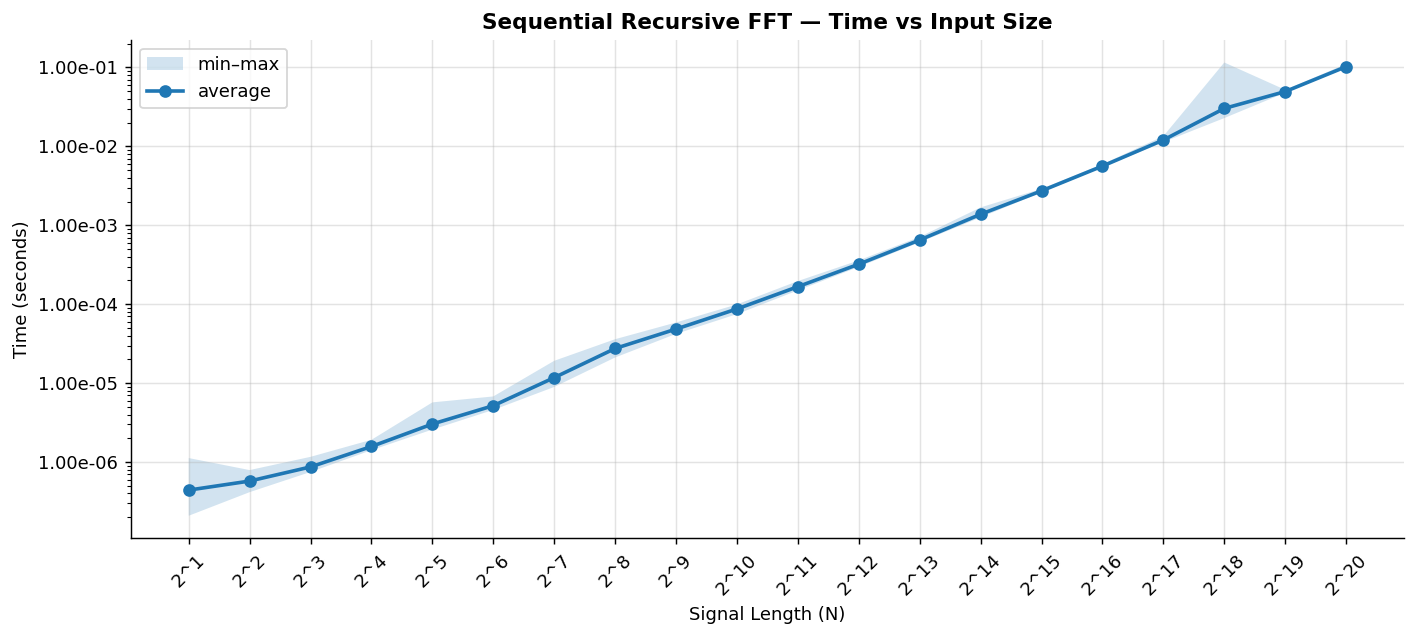

In [5]:
# Plot: Sequential Recursive — Time vs Signal Size
rows = [r for r in seq_rec_results if r['avg'] is not None]
xi   = list(range(len(rows)))
xlabs = [f"2^{int(math.log2(r['length']))}" for r in rows]

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(xi, [r['min'] for r in rows], [r['max'] for r in rows], alpha=0.2, label='min–max')
ax.plot(xi, [r['avg'] for r in rows], 'o-', linewidth=2, label='average')
ax.set_xticks(xi); ax.set_xticklabels(xlabs, rotation=45)
ax.set_xlabel('Signal Length (N)'); ax.set_ylabel('Time (seconds)')
ax.set_title('Sequential Recursive FFT — Time vs Input Size', fontweight='bold')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
ax.legend(); plt.tight_layout(); plt.show()


# Sequential Iterative


In [6]:
SEQ_IT_CPP    = "../src/cooley_tukey_iterative.cpp"  # ← update path if needed
SEQ_IT_BIN    = "./bin_seq_it"
SEQ_IT_CSV    = "seq_iterative.csv"
SEQ_IT_FLAGS  = ["-O2", "-std=c++17"]
SEQ_IT_RUNS   = 20
SEQ_IT_SIZES  = [2**p for p in range(1, 21)]   # 2^1 … 2^20

In [7]:
compile_cpp(SEQ_IT_CPP, SEQ_IT_BIN, SEQ_IT_FLAGS)

seq_it_results = []
t0 = time.time()
for i, length in enumerate(SEQ_IT_SIZES, 1):
    r = benchmark_sequential(SEQ_IT_BIN, length, SEQ_IT_RUNS)
    seq_it_results.append(r)
    avg_str = f"{r['avg']:.6f}s" if r['avg'] else "FAILED"
    print(f"[{i:>2}/{len(SEQ_IT_SIZES)}] N=2^{int(math.log2(length)):<2} ({length:<8}) avg={avg_str}")

print(f"\nDone in {time.time()-t0:.1f}s")
save_csv_sequential(seq_it_results, SEQ_IT_CSV)

Compiling: g++ ../src/cooley_tukey_iterative.cpp -o ./bin_seq_it -O2 -std=c++17
[OK] Compiled

[ 1/20] N=2^1  (2       ) avg=0.000000s
[ 2/20] N=2^2  (4       ) avg=0.000000s
[ 3/20] N=2^3  (8       ) avg=0.000000s
[ 4/20] N=2^4  (16      ) avg=0.000000s
[ 5/20] N=2^5  (32      ) avg=0.000001s
[ 6/20] N=2^6  (64      ) avg=0.000001s
[ 7/20] N=2^7  (128     ) avg=0.000002s
[ 8/20] N=2^8  (256     ) avg=0.000003s
[ 9/20] N=2^9  (512     ) avg=0.000007s
[10/20] N=2^10 (1024    ) avg=0.000015s
[11/20] N=2^11 (2048    ) avg=0.000032s
[12/20] N=2^12 (4096    ) avg=0.000069s
[13/20] N=2^13 (8192    ) avg=0.000139s
[14/20] N=2^14 (16384   ) avg=0.000311s
[15/20] N=2^15 (32768   ) avg=0.000657s
[16/20] N=2^16 (65536   ) avg=0.001291s
[17/20] N=2^17 (131072  ) avg=0.002805s
[18/20] N=2^18 (262144  ) avg=0.006232s
[19/20] N=2^19 (524288  ) avg=0.013201s
[20/20] N=2^20 (1048576 ) avg=0.028142s

Done in 49.5s
[CSV] Saved 20 rows → seq_iterative.csv


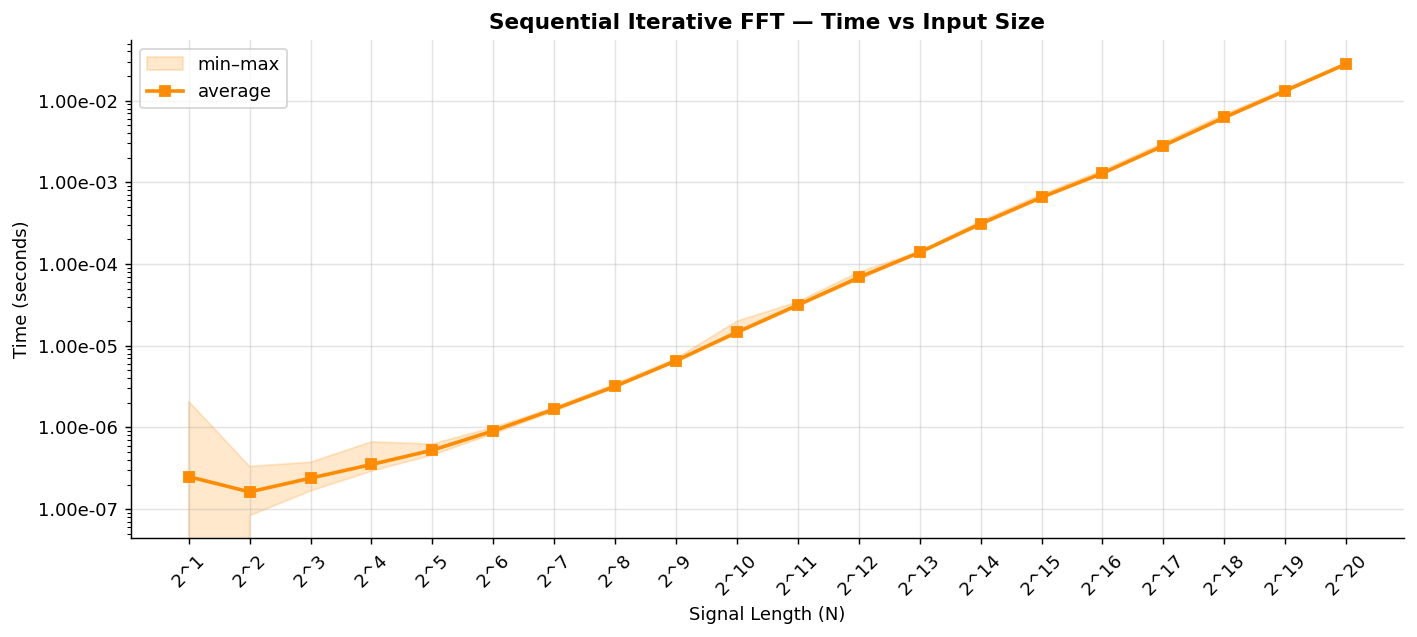

In [8]:
# Plot: Sequential Iterative — Time vs Signal Size
rows = [r for r in seq_it_results if r['avg'] is not None]
xi   = list(range(len(rows)))
xlabs = [f"2^{int(math.log2(r['length']))}" for r in rows]

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(xi, [r['min'] for r in rows], [r['max'] for r in rows], alpha=0.2, color='darkorange', label='min–max')
ax.plot(xi, [r['avg'] for r in rows], 's-', color='darkorange', linewidth=2, label='average')
ax.set_xticks(xi); ax.set_xticklabels(xlabs, rotation=45)
ax.set_xlabel('Signal Length (N)'); ax.set_ylabel('Time (seconds)')
ax.set_title('Sequential Iterative FFT — Time vs Input Size', fontweight='bold')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
ax.legend(); plt.tight_layout(); plt.show()

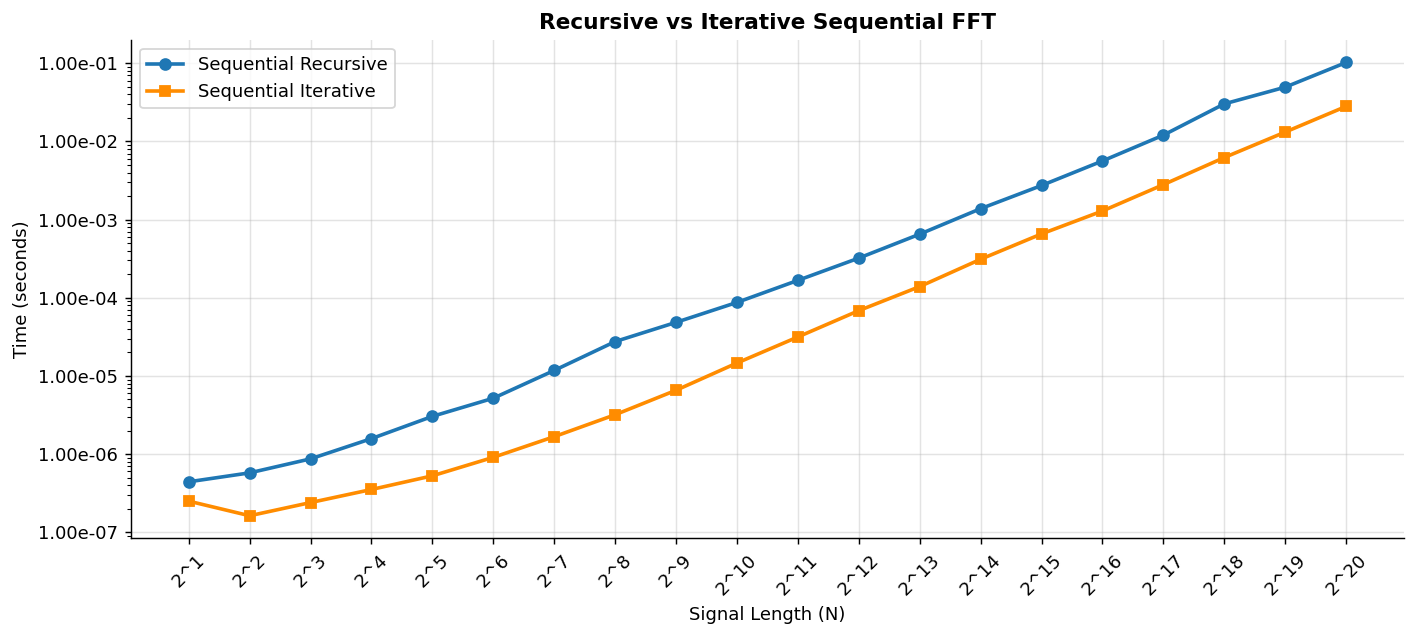

In [9]:
# Plot: Recursive vs Iterative Sequential — side-by-side comparison
seq_rec_data = load_csv_sequential(SEQ_REC_CSV)
seq_it_data  = load_csv_sequential(SEQ_IT_CSV)

common = sorted(set(seq_rec_data) & set(seq_it_data))
xi = list(range(len(common)))
xlabs = [f"2^{int(math.log2(s))}" for s in common]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(xi, [seq_rec_data[s] for s in common], 'o-', linewidth=2, label='Sequential Recursive')
ax.plot(xi, [seq_it_data[s]  for s in common], 's-', color='darkorange', linewidth=2, label='Sequential Iterative')
ax.set_xticks(xi); ax.set_xticklabels(xlabs, rotation=45)
ax.set_xlabel('Signal Length (N)'); ax.set_ylabel('Time (seconds)')
ax.set_title('Recursive vs Iterative Sequential FFT', fontweight='bold')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
ax.legend(); plt.tight_layout(); plt.show()


#  Recursive Parallel 

In [10]:
REC_PAR_CPP    = "../src/cooley_tukey_recursive_parallel.cpp"  # ← update path if needed
REC_PAR_BIN    = "./bin_rec_par"
REC_PAR_CSV    = "rec_parallel.csv"
REC_PAR_FLAGS  = ["-O2", "-std=c++17", "-pthread"]
REC_PAR_RUNS   = 20
REC_PAR_SIZES   = [2**p for p in range(1, 21)]   # 2^1 … 2^20
REC_PAR_THREADS = [2**p for p in range(0, 7)]    # 1, 2, 4, 8, 16, 32, 64

In [11]:
compile_cpp(REC_PAR_CPP, REC_PAR_BIN, REC_PAR_FLAGS)

rec_par_results = []
total = len(REC_PAR_SIZES) * len(REC_PAR_THREADS)
done  = 0
t0    = time.time()

for length in REC_PAR_SIZES:
    for threads in REC_PAR_THREADS:
        done += 1
        r = benchmark_parallel(REC_PAR_BIN, threads, length, REC_PAR_RUNS)
        rec_par_results.append(r)
        avg_str = f"{r['avg']:.6f}s (ok={r['valid']}/{REC_PAR_RUNS})" if r['avg'] else "FAILED"
        power = int(math.log2(length))
        print(f"[{done:>3}/{total}] N=2^{power:<2} T={threads:<3} | avg={avg_str}")

print(f"\nDone in {time.time()-t0:.1f}s")
save_csv_parallel(rec_par_results, REC_PAR_CSV)

Compiling: g++ ../src/cooley_tukey_recursive_parallel.cpp -o ./bin_rec_par -O2 -std=c++17 -pthread
[OK] Compiled

[  1/140] N=2^1  T=1   | avg=0.000000s (ok=20/20)
[  2/140] N=2^1  T=2   | avg=0.000000s (ok=20/20)
[  3/140] N=2^1  T=4   | avg=0.000000s (ok=20/20)
[  4/140] N=2^1  T=8   | avg=0.000000s (ok=20/20)
[  5/140] N=2^1  T=16  | avg=0.000000s (ok=20/20)
[  6/140] N=2^1  T=32  | avg=0.000000s (ok=20/20)
[  7/140] N=2^1  T=64  | avg=0.000000s (ok=20/20)
[  8/140] N=2^2  T=1   | avg=0.000001s (ok=20/20)
[  9/140] N=2^2  T=2   | avg=0.000001s (ok=20/20)
[ 10/140] N=2^2  T=4   | avg=0.000001s (ok=20/20)
[ 11/140] N=2^2  T=8   | avg=0.000001s (ok=20/20)
[ 12/140] N=2^2  T=16  | avg=0.000001s (ok=20/20)
[ 13/140] N=2^2  T=32  | avg=0.000001s (ok=20/20)
[ 14/140] N=2^2  T=64  | avg=0.000001s (ok=20/20)
[ 15/140] N=2^3  T=1   | avg=0.000001s (ok=20/20)
[ 16/140] N=2^3  T=2   | avg=0.000001s (ok=20/20)
[ 17/140] N=2^3  T=4   | avg=0.000001s (ok=20/20)
[ 18/140] N=2^3  T=8   | avg=0.00000

In [12]:
# ── Recursive Parallel Speedup Analysis ──────────────────
seq_baseline = load_csv_sequential(SEQ_REC_CSV)  # sequential recursive as baseline
par_data     = load_csv_parallel(REC_PAR_CSV)

overlap     = sorted(s for s in set(k[1] for k in par_data) if s in seq_baseline)
all_threads = sorted(set(k[0] for k in par_data))

print("=" * 90)
print("RECURSIVE PARALLEL — Speedup vs Sequential Recursive")
print("=" * 90)

for t in all_threads:
    print(f"\n{'  THREADS: ' + str(t) + '  ':=^90}")
    print(f"{'Signal Size':>15} | {'Power':>5} | {'Seq Time':>12} | {'Par Time':>12} | {'Speedup':>10}")
    print("-" * 90)
    for s in overlap:
        if (t, s) in par_data:
            sp = seq_baseline[s] / par_data[(t, s)]
            print(f"{s:>15} | {int(math.log2(s)):>5} | {seq_baseline[s]:>12.6e} | {par_data[(t,s)]:>12.6e} | {sp:>10.4f}x")
print("\n" + "=" * 90)

RECURSIVE PARALLEL — Speedup vs Sequential Recursive

======================================  THREADS: 1  ======================================
    Signal Size | Power |     Seq Time |     Par Time |    Speedup
------------------------------------------------------------------------------------------
              2 |     1 | 4.417500e-07 | 3.895500e-07 |     1.1340x
              4 |     2 | 5.751000e-07 | 5.710000e-07 |     1.0072x
              8 |     3 | 8.687000e-07 | 1.300000e-06 |     0.6682x
             16 |     4 | 1.577000e-06 | 1.814500e-06 |     0.8691x
             32 |     5 | 3.037500e-06 | 3.106400e-06 |     0.9778x
             64 |     6 | 5.185550e-06 | 5.602050e-06 |     0.9257x
            128 |     7 | 1.175835e-05 | 1.039810e-05 |     1.1308x
            256 |     8 | 2.751675e-05 | 2.540855e-05 |     1.0830x
            512 |     9 | 4.849175e-05 | 4.684160e-05 |     1.0352x
           1024 |    10 | 8.724790e-05 | 9.014165e-05 |     0.9679x
           2048 |

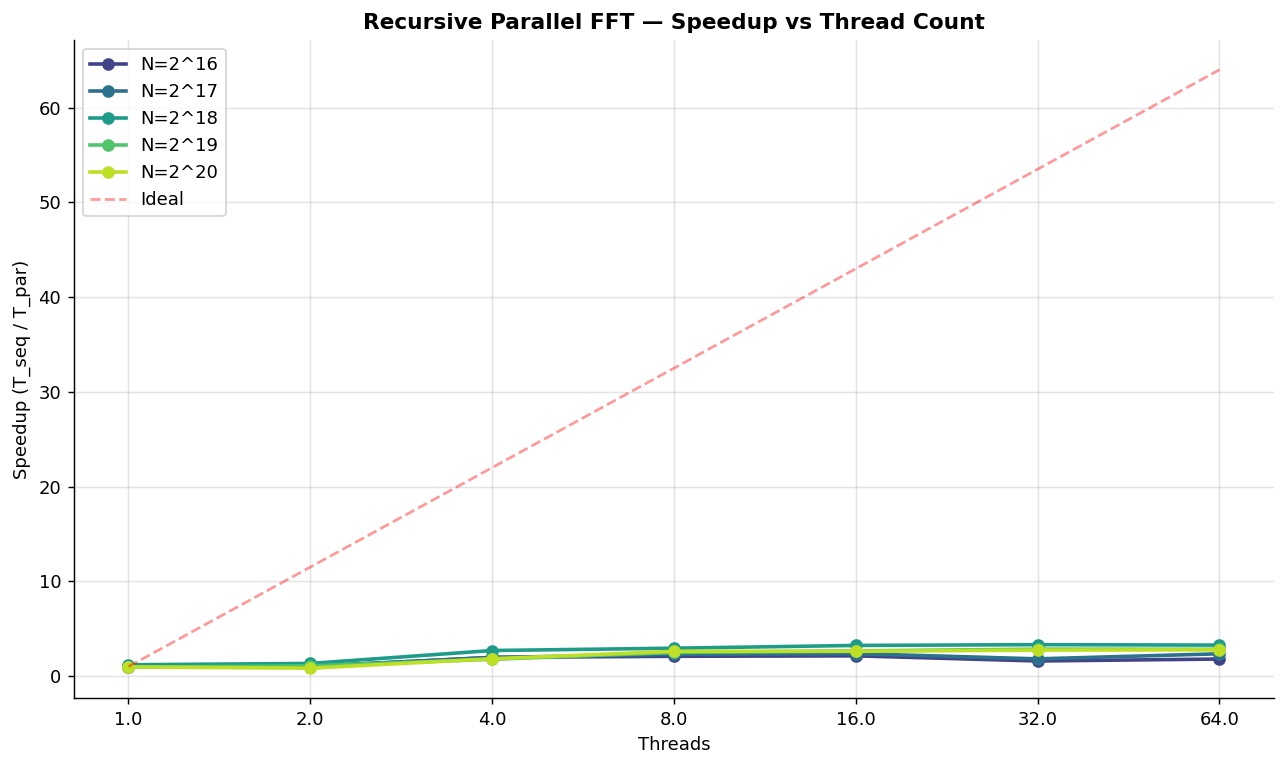

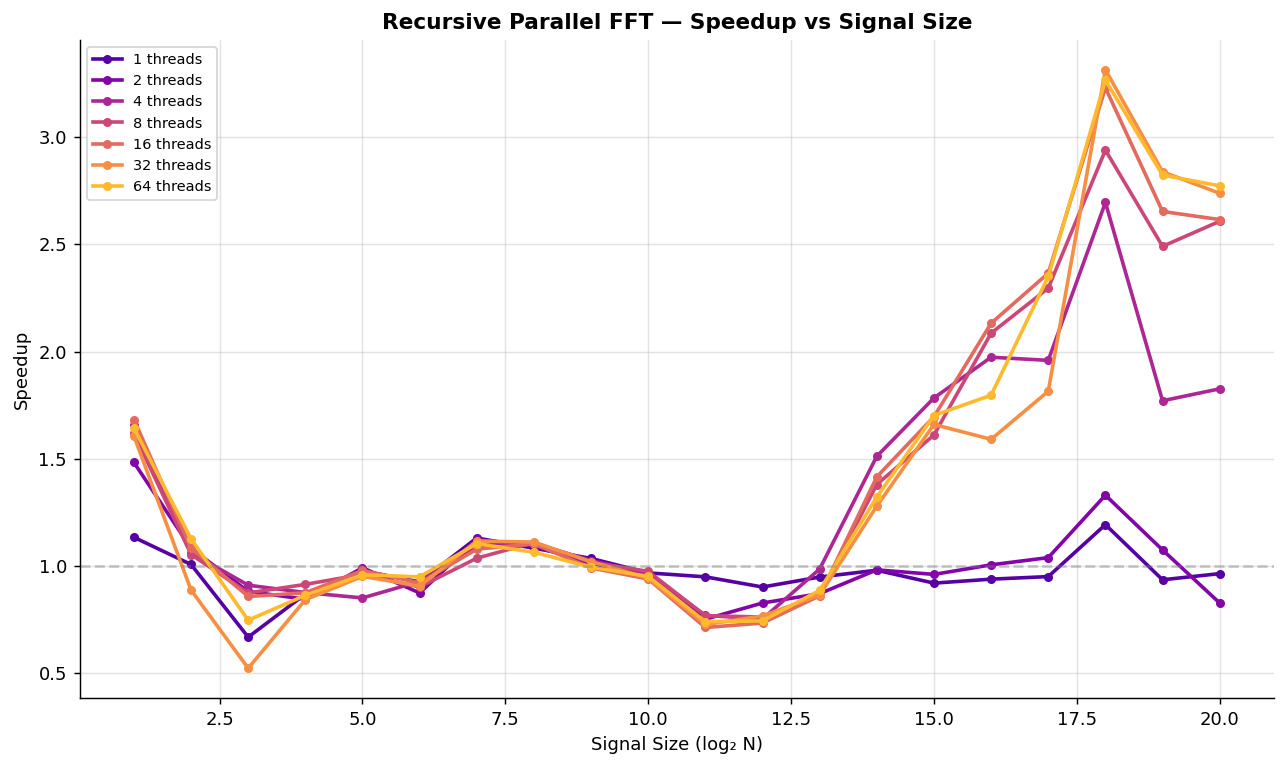

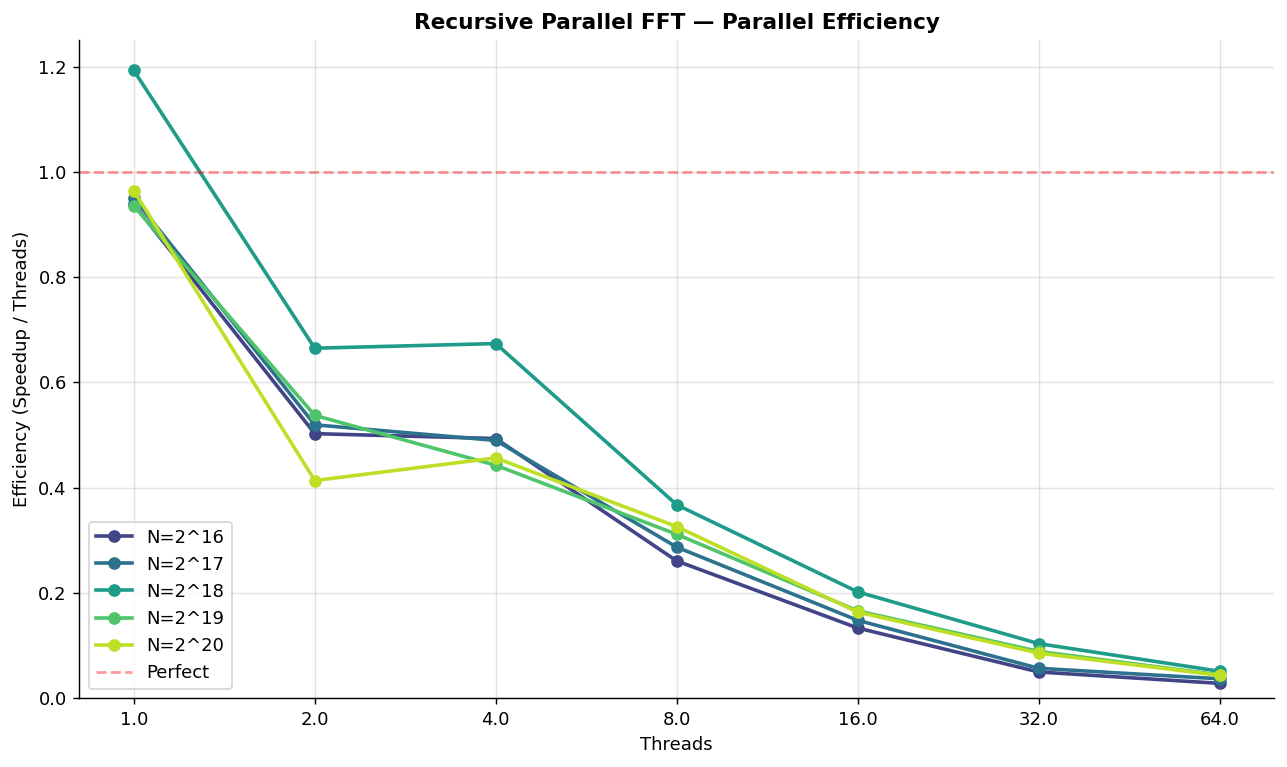

In [13]:
# Plot 1: Speedup vs Threads (large sizes)
seq_baseline = load_csv_sequential(SEQ_REC_CSV)
par_data     = load_csv_parallel(REC_PAR_CSV)
overlap     = sorted(s for s in set(k[1] for k in par_data) if s in seq_baseline)
all_threads = sorted(set(k[0] for k in par_data))

plot_sizes = overlap[-5:]   # 5 largest sizes
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(plot_sizes)))

fig, ax = plt.subplots(figsize=(10, 6))
for s, c in zip(plot_sizes, colors):
    p = int(math.log2(s))
    xs = [t for t in all_threads if (t,s) in par_data]
    ys = [seq_baseline[s] / par_data[(t,s)] for t in xs]
    ax.plot(xs, ys, 'o-', color=c, linewidth=2, markersize=6, label=f'N=2^{p}')
ax.plot([1, max(all_threads)], [1, max(all_threads)], '--', color='red', alpha=0.4, linewidth=1.5, label='Ideal')
ax.set_xscale('log', base=2); ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xlabel('Threads'); ax.set_ylabel('Speedup (T_seq / T_par)')
ax.set_title('Recursive Parallel FFT — Speedup vs Thread Count', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# Plot 2: Speedup vs Size (per thread count)
fig, ax = plt.subplots(figsize=(10, 6))
colors2 = plt.cm.plasma(np.linspace(0.15, 0.85, len(all_threads)))
for t, c in zip(all_threads, colors2):
    xs = [int(math.log2(s)) for s in overlap if (t,s) in par_data]
    ys = [seq_baseline[s] / par_data[(t,s)] for s in overlap if (t,s) in par_data]
    ax.plot(xs, ys, 'o-', color=c, linewidth=2, markersize=4, label=f'{t} threads')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Signal Size (log₂ N)'); ax.set_ylabel('Speedup')
ax.set_title('Recursive Parallel FFT — Speedup vs Signal Size', fontweight='bold')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# Plot 3: Parallel Efficiency
fig, ax = plt.subplots(figsize=(10, 6))
for s, c in zip(plot_sizes, colors):
    p = int(math.log2(s))
    xs = [t for t in all_threads if (t,s) in par_data]
    ys = [(seq_baseline[s] / par_data[(t,s)]) / t for t in xs]
    ax.plot(xs, ys, 'o-', color=c, linewidth=2, markersize=6, label=f'N=2^{p}')
ax.axhline(1.0, color='red', linestyle='--', alpha=0.4, label='Perfect')
ax.set_xscale('log', base=2); ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xlabel('Threads'); ax.set_ylabel('Efficiency (Speedup / Threads)')
ax.set_title('Recursive Parallel FFT — Parallel Efficiency', fontweight='bold')
ax.set_ylim(bottom=0); ax.legend(); plt.tight_layout(); plt.show()


# Iterative Parallel 

In [14]:
IT_PAR_CPP    = "../src/cooley_tukey_iterative_parallel.cpp"  # ← update path if needed
IT_PAR_BIN    = "./bin_it_par"
IT_PAR_CSV    = "iter_parallel.csv"
IT_PAR_FLAGS  = ["-O2", "-std=c++17", "-pthread"]
IT_PAR_RUNS   = 20
IT_PAR_SIZES   = [2**p for p in range(1, 21)]   # 2^1 … 2^20
IT_PAR_THREADS = [2**p for p in range(0, 7)]    # 1, 2, 4, 8, 16, 32, 64

In [17]:
compile_cpp(IT_PAR_CPP, IT_PAR_BIN, IT_PAR_FLAGS)

it_par_results = []
total = len(IT_PAR_SIZES) * len(IT_PAR_THREADS)
done  = 0
t0    = time.time()

for length in IT_PAR_SIZES:
    for threads in IT_PAR_THREADS:
        done += 1
        r = benchmark_parallel(IT_PAR_BIN, threads, length, IT_PAR_RUNS)
        it_par_results.append(r)
        avg_str = f"{r['avg']:.6f}s (ok={r['valid']}/{IT_PAR_RUNS})" if r['avg'] else "FAILED"
        power = int(math.log2(length))
        print(f"[{done:>3}/{total}] N=2^{power:<2} T={threads:<3} | avg={avg_str}")

print(f"\nDone in {time.time()-t0:.1f}s")
save_csv_parallel(it_par_results, IT_PAR_CSV)

Compiling: g++ ../src/cooley_tukey_iterative_parallel.cpp -o ./bin_it_par -O2 -std=c++17 -pthread
[OK] Compiled

[  1/140] N=2^1  T=1   | avg=0.000019s (ok=20/20)
[  2/140] N=2^1  T=2   | avg=0.000022s (ok=20/20)
[  3/140] N=2^1  T=4   | avg=0.000034s (ok=16/20)
[  4/140] N=2^1  T=8   | avg=0.000061s (ok=15/20)
[  5/140] N=2^1  T=16  | avg=0.000120s (ok=16/20)
[  6/140] N=2^1  T=32  | avg=0.000225s (ok=14/20)
[  7/140] N=2^1  T=64  | avg=0.000466s (ok=14/20)
[  8/140] N=2^2  T=1   | avg=0.000030s (ok=20/20)
[  9/140] N=2^2  T=2   | avg=0.000045s (ok=20/20)
[ 10/140] N=2^2  T=4   | avg=0.000079s (ok=20/20)
[ 11/140] N=2^2  T=8   | avg=0.000138s (ok=20/20)
[ 12/140] N=2^2  T=16  | avg=0.000257s (ok=20/20)
[ 13/140] N=2^2  T=32  | avg=0.000504s (ok=20/20)
[ 14/140] N=2^2  T=64  | avg=0.001024s (ok=20/20)
[ 15/140] N=2^3  T=1   | avg=0.000049s (ok=20/20)
[ 16/140] N=2^3  T=2   | avg=0.000069s (ok=20/20)
[ 17/140] N=2^3  T=4   | avg=0.000109s (ok=20/20)
[ 18/140] N=2^3  T=8   | avg=0.000197

In [18]:
# ── Iterative Parallel Speedup Analysis ───────────────────
seq_baseline = load_csv_sequential(SEQ_IT_CSV)   # sequential iterative as baseline
par_data     = load_csv_parallel(IT_PAR_CSV)

overlap     = sorted(s for s in set(k[1] for k in par_data) if s in seq_baseline)
all_threads = sorted(set(k[0] for k in par_data))

print("=" * 90)
print("ITERATIVE PARALLEL — Speedup vs Sequential Iterative")
print("=" * 90)

for t in all_threads:
    print(f"\n{'  THREADS: ' + str(t) + '  ':=^90}")
    print(f"{'Signal Size':>15} | {'Power':>5} | {'Seq Time':>12} | {'Par Time':>12} | {'Speedup':>10}")
    print("-" * 90)
    for s in overlap:
        if (t, s) in par_data:
            sp = seq_baseline[s] / par_data[(t, s)]
            print(f"{s:>15} | {int(math.log2(s)):>5} | {seq_baseline[s]:>12.6e} | {par_data[(t,s)]:>12.6e} | {sp:>10.4f}x")
print("\n" + "=" * 90)

ITERATIVE PARALLEL — Speedup vs Sequential Iterative

======================================  THREADS: 1  ======================================
    Signal Size | Power |     Seq Time |     Par Time |    Speedup
------------------------------------------------------------------------------------------
              2 |     1 | 2.499000e-07 | 1.873140e-05 |     0.0133x
              4 |     2 | 1.625000e-07 | 3.027930e-05 |     0.0054x
              8 |     3 | 2.397000e-07 | 4.904370e-05 |     0.0049x
             16 |     4 | 3.521500e-07 | 6.230625e-05 |     0.0057x
             32 |     5 | 5.270500e-07 | 7.526240e-05 |     0.0070x
             64 |     6 | 9.084500e-07 | 9.492100e-05 |     0.0096x
            128 |     7 | 1.670800e-06 | 1.100938e-04 |     0.0152x
            256 |     8 | 3.189600e-06 | 1.218209e-04 |     0.0262x
            512 |     9 | 6.558400e-06 | 1.421208e-04 |     0.0461x
           1024 |    10 | 1.463330e-05 | 1.592772e-04 |     0.0919x
           2048 |

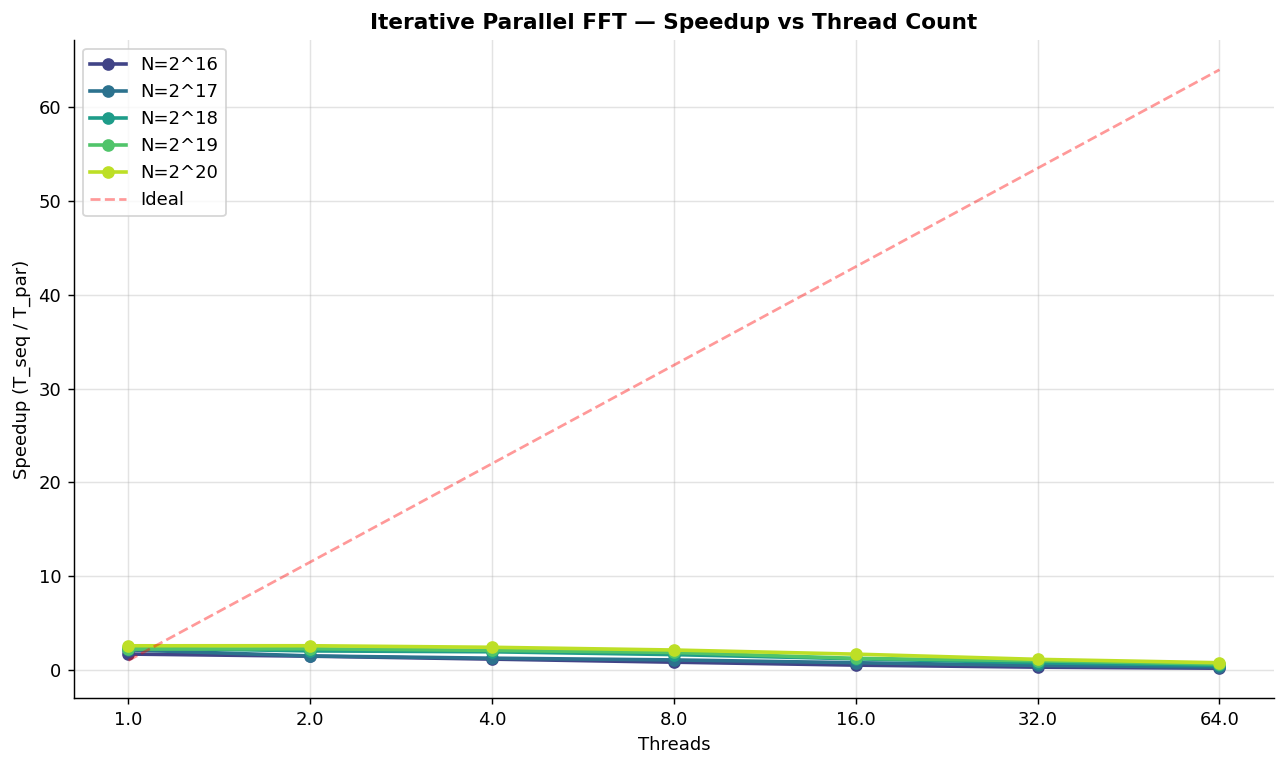

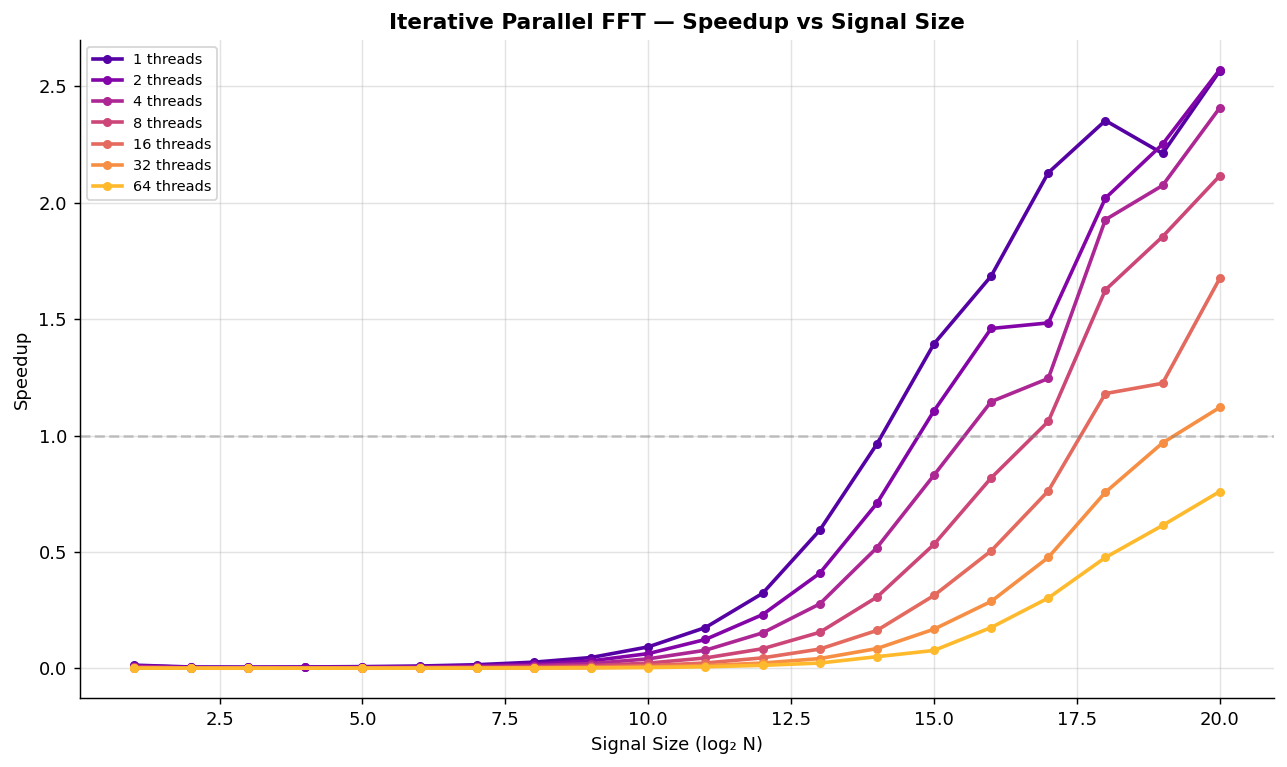

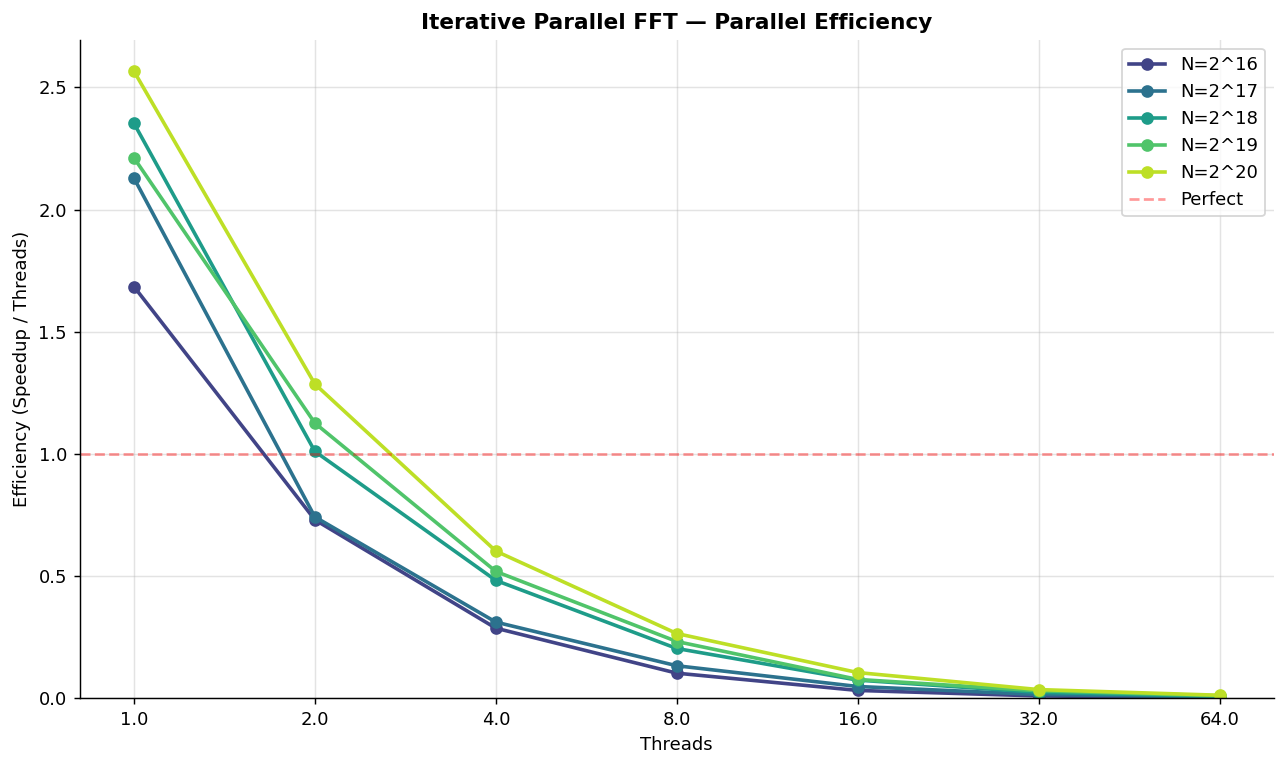

In [22]:
# Plot 1: Speedup vs Threads (large sizes)
seq_baseline = load_csv_sequential(SEQ_IT_CSV)
par_data     = load_csv_parallel(IT_PAR_CSV)
overlap     = sorted(s for s in set(k[1] for k in par_data) if s in seq_baseline)
all_threads = sorted(set(k[0] for k in par_data))

plot_sizes = overlap[-5:]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(plot_sizes)))

fig, ax = plt.subplots(figsize=(10, 6))
for s, c in zip(plot_sizes, colors):
    p = int(math.log2(s))
    xs = [t for t in all_threads if (t,s) in par_data]
    ys = [seq_baseline[s] / par_data[(t,s)] for t in xs]
    ax.plot(xs, ys, 'o-', color=c, linewidth=2, markersize=6, label=f'N=2^{p}')
ax.plot([1, max(all_threads)], [1, max(all_threads)], '--', color='red', alpha=0.4, linewidth=1.5, label='Ideal')
ax.set_xscale('log', base=2); ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xlabel('Threads'); ax.set_ylabel('Speedup (T_seq / T_par)')
ax.set_title('Iterative Parallel FFT — Speedup vs Thread Count', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# Plot 2: Speedup vs Size (per thread count)
fig, ax = plt.subplots(figsize=(10, 6))
colors2 = plt.cm.plasma(np.linspace(0.15, 0.85, len(all_threads)))
for t, c in zip(all_threads, colors2):
    xs = [int(math.log2(s)) for s in overlap if (t,s) in par_data]
    ys = [seq_baseline[s] / par_data[(t,s)] for s in overlap if (t,s) in par_data]
    ax.plot(xs, ys, 'o-', color=c, linewidth=2, markersize=4, label=f'{t} threads')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Signal Size (log₂ N)'); ax.set_ylabel('Speedup')
ax.set_title('Iterative Parallel FFT — Speedup vs Signal Size', fontweight='bold')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# Plot 3: Parallel Efficiency
fig, ax = plt.subplots(figsize=(10, 6))
for s, c in zip(plot_sizes, colors):
    p = int(math.log2(s))
    xs = [t for t in all_threads if (t,s) in par_data]
    ys = [(seq_baseline[s] / par_data[(t,s)]) / t for t in xs]
    ax.plot(xs, ys, 'o-', color=c, linewidth=2, markersize=6, label=f'N=2^{p}')
ax.axhline(1.0, color='red', linestyle='--', alpha=0.4, label='Perfect')
ax.set_xscale('log', base=2); ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xlabel('Threads'); ax.set_ylabel('Efficiency (Speedup / Threads)')
ax.set_title('Iterative Parallel FFT — Parallel Efficiency', fontweight='bold')
ax.set_ylim(bottom=0); ax.legend(); plt.tight_layout(); plt.show()

In [23]:
import csv
import math

# ── Load ──────────────────────────────────────────────────
seq_data = {}
with open("seq_recursive.csv") as f:
    for row in csv.DictReader(f):
        if row["avg"] not in ("", "None"):
            seq_data[int(row["length"])] = float(row["avg"])

par_data = {}
with open("iter_parallel.csv") as f:
    for row in csv.DictReader(f):
        if row["avg"] not in ("", "None", "nan"):
            par_data[(int(row["threads"]), int(row["length"]))] = float(row["avg"])

overlap     = sorted(s for s in set(k[1] for k in par_data) if s in seq_data)
all_threads = sorted(set(k[0] for k in par_data))

# ── Print ─────────────────────────────────────────────────
print("=" * 90)
print("SPEEDUP: Sequential Recursive  →  Iterative Parallel")
print("=" * 90)

for t in all_threads:
    print(f"\n{'  THREADS: ' + str(t) + '  ':=^90}")
    print(f"{'Signal Size':>15} | {'Power':>5} | {'Seq-Rec Time':>14} | {'Iter-Par Time':>14} | {'Speedup':>10}")
    print("-" * 90)
    for s in overlap:
        if (t, s) in par_data:
            sp = seq_data[s] / par_data[(t, s)]
            print(f"{s:>15} | {int(math.log2(s)):>5} | "
                  f"{seq_data[s]:>14.6e} | {par_data[(t,s)]:>14.6e} | {sp:>10.4f}x")

print("\n" + "=" * 90)

SPEEDUP: Sequential Recursive  →  Iterative Parallel

======================================  THREADS: 1  ======================================
    Signal Size | Power |   Seq-Rec Time |  Iter-Par Time |    Speedup
------------------------------------------------------------------------------------------
              2 |     1 |   4.417500e-07 |   1.873140e-05 |     0.0236x
              4 |     2 |   5.751000e-07 |   3.027930e-05 |     0.0190x
              8 |     3 |   8.687000e-07 |   4.904370e-05 |     0.0177x
             16 |     4 |   1.577000e-06 |   6.230625e-05 |     0.0253x
             32 |     5 |   3.037500e-06 |   7.526240e-05 |     0.0404x
             64 |     6 |   5.185550e-06 |   9.492100e-05 |     0.0546x
            128 |     7 |   1.175835e-05 |   1.100938e-04 |     0.1068x
            256 |     8 |   2.751675e-05 |   1.218209e-04 |     0.2259x
            512 |     9 |   4.849175e-05 |   1.421208e-04 |     0.3412x
           1024 |    10 |   8.724790e-05 |   

# Bailey Sequential

In [24]:
SEQ_IT_CPP    = "/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/bailey_sequential.cpp"  # ← update path if needed
SEQ_IT_BIN    = "./bin_seq_bailey"
SEQ_IT_CSV    = "seq_bailey.csv"
SEQ_IT_FLAGS  = ["-O2", "-std=c++17"]
SEQ_IT_RUNS   = 20
SEQ_IT_SIZES  = [2**p for p in range(1, 21)]   # 2^1 … 2^20

In [25]:
compile_cpp(SEQ_REC_CPP, SEQ_REC_BIN, SEQ_REC_FLAGS)

seq_bailey_results = []
t0 = time.time()
for i, length in enumerate(SEQ_REC_SIZES, 1):
    r = benchmark_sequential(SEQ_REC_BIN, length, SEQ_REC_RUNS)
    seq_bailey_results.append(r)
    avg_str = f"{r['avg']:.6f}s" if r['avg'] else "FAILED"
    print(f"[{i:>2}/{len(SEQ_REC_SIZES)}] N=2^{int(math.log2(length)):<2} ({length:<8}) avg={avg_str}")

print(f"\nDone in {time.time()-t0:.1f}s")
save_csv_sequential(seq_bailey_results, SEQ_IT_CSV)

Compiling: g++ ../src/cooley_tukey_sequential.cpp -o ./bin_seq_rec -O2 -std=c++17
[OK] Compiled

[ 1/20] N=2^1  (2       ) avg=0.000000s
[ 2/20] N=2^2  (4       ) avg=0.000001s
[ 3/20] N=2^3  (8       ) avg=0.000001s
[ 4/20] N=2^4  (16      ) avg=0.000002s
[ 5/20] N=2^5  (32      ) avg=0.000003s
[ 6/20] N=2^6  (64      ) avg=0.000006s
[ 7/20] N=2^7  (128     ) avg=0.000012s
[ 8/20] N=2^8  (256     ) avg=0.000026s
[ 9/20] N=2^9  (512     ) avg=0.000058s
[10/20] N=2^10 (1024    ) avg=0.000087s
[11/20] N=2^11 (2048    ) avg=0.000162s
[12/20] N=2^12 (4096    ) avg=0.000320s
[13/20] N=2^13 (8192    ) avg=0.000662s
[14/20] N=2^14 (16384   ) avg=0.001357s
[15/20] N=2^15 (32768   ) avg=0.002698s
[16/20] N=2^16 (65536   ) avg=0.005647s
[17/20] N=2^17 (131072  ) avg=0.012038s
[18/20] N=2^18 (262144  ) avg=0.024232s
[19/20] N=2^19 (524288  ) avg=0.061704s
[20/20] N=2^20 (1048576 ) avg=0.104054s

Done in 54.3s
[CSV] Saved 20 rows → seq_bailey.csv


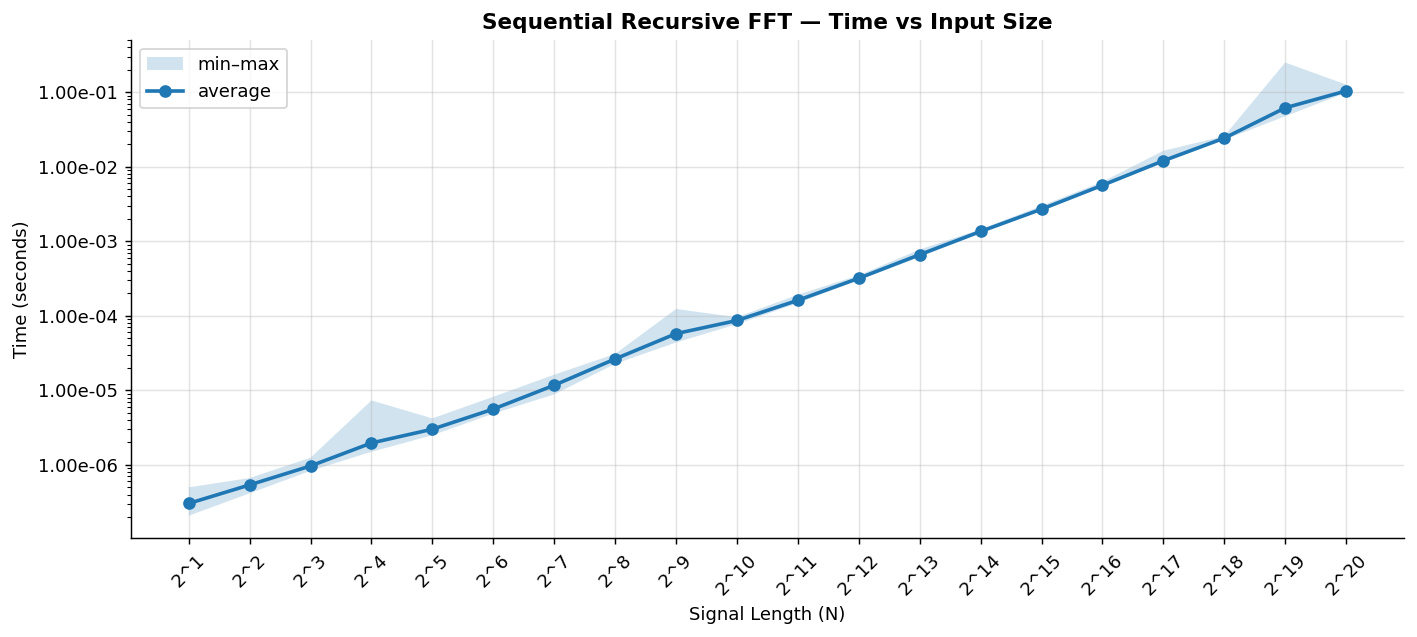

In [27]:
# Plot: Sequential Recursive — Time vs Signal Size
rows = [r for r in seq_bailey_results if r['avg'] is not None]
xi   = list(range(len(rows)))
xlabs = [f"2^{int(math.log2(r['length']))}" for r in rows]

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(xi, [r['min'] for r in rows], [r['max'] for r in rows], alpha=0.2, label='min–max')
ax.plot(xi, [r['avg'] for r in rows], 'o-', linewidth=2, label='average')
ax.set_xticks(xi); ax.set_xticklabels(xlabs, rotation=45)
ax.set_xlabel('Signal Length (N)'); ax.set_ylabel('Time (seconds)')
ax.set_title('Sequential Recursive FFT — Time vs Input Size', fontweight='bold')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
ax.legend(); plt.tight_layout(); plt.show()

# Bailey Parallel

In [28]:
IT_PAR_CPP    = "/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/bailey_parallel.cpp"  # ← update path if needed
IT_PAR_BIN    = "./bin_bailey_par"
IT_PAR_CSV    = "bailey_parallel.csv"
IT_PAR_FLAGS  = ["-O2", "-std=c++17", "-pthread"]
IT_PAR_RUNS   = 20
IT_PAR_SIZES   = [2**p for p in range(1, 21)]   # 2^1 … 2^20
IT_PAR_THREADS = [2**p for p in range(0, 7)]    # 1, 2, 4, 8, 16, 32, 64

In [29]:
compile_cpp(IT_PAR_CPP, IT_PAR_BIN, IT_PAR_FLAGS)

bailey_par_results = []
total = len(IT_PAR_SIZES) * len(IT_PAR_THREADS)
done  = 0
t0    = time.time()

for length in IT_PAR_SIZES:
    for threads in IT_PAR_THREADS:
        done += 1
        r = benchmark_parallel(IT_PAR_BIN, threads, length, IT_PAR_RUNS)
        bailey_par_results.append(r)
        avg_str = f"{r['avg']:.6f}s (ok={r['valid']}/{IT_PAR_RUNS})" if r['avg'] else "FAILED"
        power = int(math.log2(length))
        print(f"[{done:>3}/{total}] N=2^{power:<2} T={threads:<3} | avg={avg_str}")

print(f"\nDone in {time.time()-t0:.1f}s")
save_csv_parallel(bailey_par_results, IT_PAR_CSV)

Compiling: g++ /Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/bailey_parallel.cpp -o ./bin_bailey_par -O2 -std=c++17 -pthread
[OK] Compiled

[  1/140] N=2^1  T=1   | avg=0.000117s (ok=20/20)
[  2/140] N=2^1  T=2   | avg=0.000136s (ok=20/20)
[  3/140] N=2^1  T=4   | avg=0.000212s (ok=20/20)
[  4/140] N=2^1  T=8   | avg=0.000388s (ok=20/20)
[  5/140] N=2^1  T=16  | avg=0.000727s (ok=20/20)
[  6/140] N=2^1  T=32  | avg=0.001430s (ok=20/20)
[  7/140] N=2^1  T=64  | avg=0.002987s (ok=20/20)
[  8/140] N=2^2  T=1   | avg=0.000104s (ok=20/20)
[  9/140] N=2^2  T=2   | avg=0.000136s (ok=20/20)
[ 10/140] N=2^2  T=4   | avg=0.000227s (ok=20/20)
[ 11/140] N=2^2  T=8   | avg=0.000384s (ok=20/20)
[ 12/140] N=2^2  T=16  | avg=0.000724s (ok=20/20)
[ 13/140] N=2^2  T=32  | avg=0.001451s (ok=20/20)
[ 14/140] N=2^2  T=64  | avg=0.002920s (ok=20/20)
[ 15/140] N=2^3  T=1   | avg=0.000090s (ok=20/20)
[ 16/140] N=2^3  T=2   | avg=0.000141s (ok=20/20)
[ 17/140] N=2^3  T=4   | avg=0.000207s (ok=20/

In [35]:
import csv
import math

# ── Load ──────────────────────────────────────────────────
seq_data = {}
with open("/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/seq_bailey.csv") as f:
    for row in csv.DictReader(f):
        if row["avg"] not in ("", "None"):
            seq_data[int(row["length"])] = float(row["avg"])

par_data = {}
with open("/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/bailey_parallel.csv") as f:
    for row in csv.DictReader(f):
        if row["avg"] not in ("", "None", "nan"):
            par_data[(int(row["threads"]), int(row["length"]))] = float(row["avg"])

overlap     = sorted(s for s in set(k[1] for k in par_data) if s in seq_data)
all_threads = sorted(set(k[0] for k in par_data))

# ── Print ─────────────────────────────────────────────────
print("=" * 90)
print("SPEEDUP: Sequential Recursive  →  Iterative Parallel")
print("=" * 90)

for t in all_threads:
    print(f"\n{'  THREADS: ' + str(t) + '  ':=^90}")
    print(f"{'Signal Size':>15} | {'Power':>5} | {'Seq-Rec Time':>14} | {'Iter-Par Time':>14} | {'Speedup':>10}")
    print("-" * 90)
    for s in overlap:
        if (t, s) in par_data:
            sp = seq_data[s] / par_data[(t, s)]
            print(f"{s:>15} | {int(math.log2(s)):>5} | "
                  f"{seq_data[s]:>14.6e} | {par_data[(t,s)]:>14.6e} | {sp:>10.4f}x")

print("\n" + "=" * 90)

SPEEDUP: Sequential Recursive  →  Iterative Parallel

======================================  THREADS: 1  ======================================
    Signal Size | Power |   Seq-Rec Time |  Iter-Par Time |    Speedup
------------------------------------------------------------------------------------------
              2 |     1 |   3.042000e-07 |   1.167833e-04 |     0.0026x
              4 |     2 |   5.395000e-07 |   1.041207e-04 |     0.0052x
              8 |     3 |   9.688000e-07 |   9.041865e-05 |     0.0107x
             16 |     4 |   1.970750e-06 |   9.433750e-05 |     0.0209x
             32 |     5 |   3.014550e-06 |   9.166455e-05 |     0.0329x
             64 |     6 |   5.610550e-06 |   1.011811e-04 |     0.0555x
            128 |     7 |   1.172095e-05 |   9.865630e-05 |     0.1188x
            256 |     8 |   2.640010e-05 |   1.065751e-04 |     0.2477x
            512 |     9 |   5.771455e-05 |   1.108124e-04 |     0.5208x
           1024 |    10 |   8.662695e-05 |   